In [1]:
import os
import datetime
import pickle
import bz2

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Geographiclib - https://geographiclib.sourceforge.io/Python/2.0/
# conda install conda-forge::geographiclib
from geographiclib.geodesic import Geodesic
geod = Geodesic.WGS84

In [2]:
plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']    = 'bold'
plt.rcParams['axes.titleweight']    = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

In [3]:
date   = datetime.datetime(2018,12,15)
frange = (14.000e6,14.350e6)

# Load Data

In [5]:
ham_dir   = 'ham_data'
ham_fname = '{!s}_{!s}-{!s}kHz_hamSpot.pkl.bz2'.format(
    date.strftime('%Y%m%d'),int(frange[0]/1e3),int(frange[1]/1e3))
ham_fpath = os.path.join(ham_dir,ham_fname)
print(ham_fpath)

ham_data/20181215_14000-14350kHz_hamSpot.pkl.bz2


In [6]:
# Load the compressed data from the file
with open(ham_fpath, "rb") as f:
    compressed_data = f.read()

# Decompress the data
pickled_data = bz2.decompress(compressed_data)

# Unpickle the data
df = pickle.loads(pickled_data)

del compressed_data
del pickled_data

In [7]:
df

,date,call_sign_tx,txlat,txlon,call_sign_rx,rxlat,rxlon,tfreq,sn,smode,ssrc,pthlen,latcen,loncen
7,2018-12-15 00:00:00,N8MDP,41.3958,-81.2083,KN3A,40.0625,-76.4583,14075455.0,-18.0,'FT8',PSK,426.8,40.7535,-78.8095
33,2018-12-15 00:00:00,W1JGM,41.4375,-73.5417,N6PAA,38.2313,-121.5792,14075301.0,-18.0,'FT8',PSK,4064.5,42.4027,-98.1565
38,2018-12-15 00:00:00,W0PE,33.8919,-117.7835,N7BT,48.8125,-122.5417,14075574.0,-20.0,'FT8',PSK,1705.1,41.3764,-119.8882
53,2018-12-15 00:00:00,RQ0C,48.5208,135.0417,JK1JAS,35.3542,139.5417,14074632.0,-9.0,'FT8',PSK,1509.9,41.9592,137.5251
54,2018-12-15 00:00:00,RQ0C,48.5208,135.0417,BG8FT,30.5625,103.5417,14074732.0,-16.0,'FT8',PSK,3320.4,40.6026,117.1847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10101657,2018-12-15 23:59:59,YB1RUS,-6.1875,106.7083,JE2UFF,34.8542,138.1250,14076053.0,-9.0,'FT8',PSK,5627.3,14.8601,120.8759
10101658,2018-12-15 23:59:59,YB1RUS,-6.1875,106.7083,JA1AZR,36.6458,140.7083,14076055.0,-4.0,'FT8',PSK,5931.9,15.8826,121.8385
10101693,2018-12-15 23:59:59,W2HTS,40.2999,-74.0707,W9HM,44.2813,-88.3792,14074407.0,-6.0,'FT8',PSK,1255.4,42.5133,-80.9975
10101775,2018-12-15 23:59:59,LU1XU,-54.8021,-68.3042,LU3XCC,-51.6354,-69.2292,14074983.0,-16.0,'FT8',PSK,357.5,-53.2196,-68.7838


# Unique TX and RX

In [9]:
# Unique Transmitters
tx_df = df[['call_sign_tx','txlat','txlon']].drop_duplicates('call_sign_tx').copy()

# Unique Receivers
rx_df = df[['call_sign_rx','rxlat','rxlon']].drop_duplicates('call_sign_rx').copy()

In [10]:
len(tx_df)

15328

# Maps

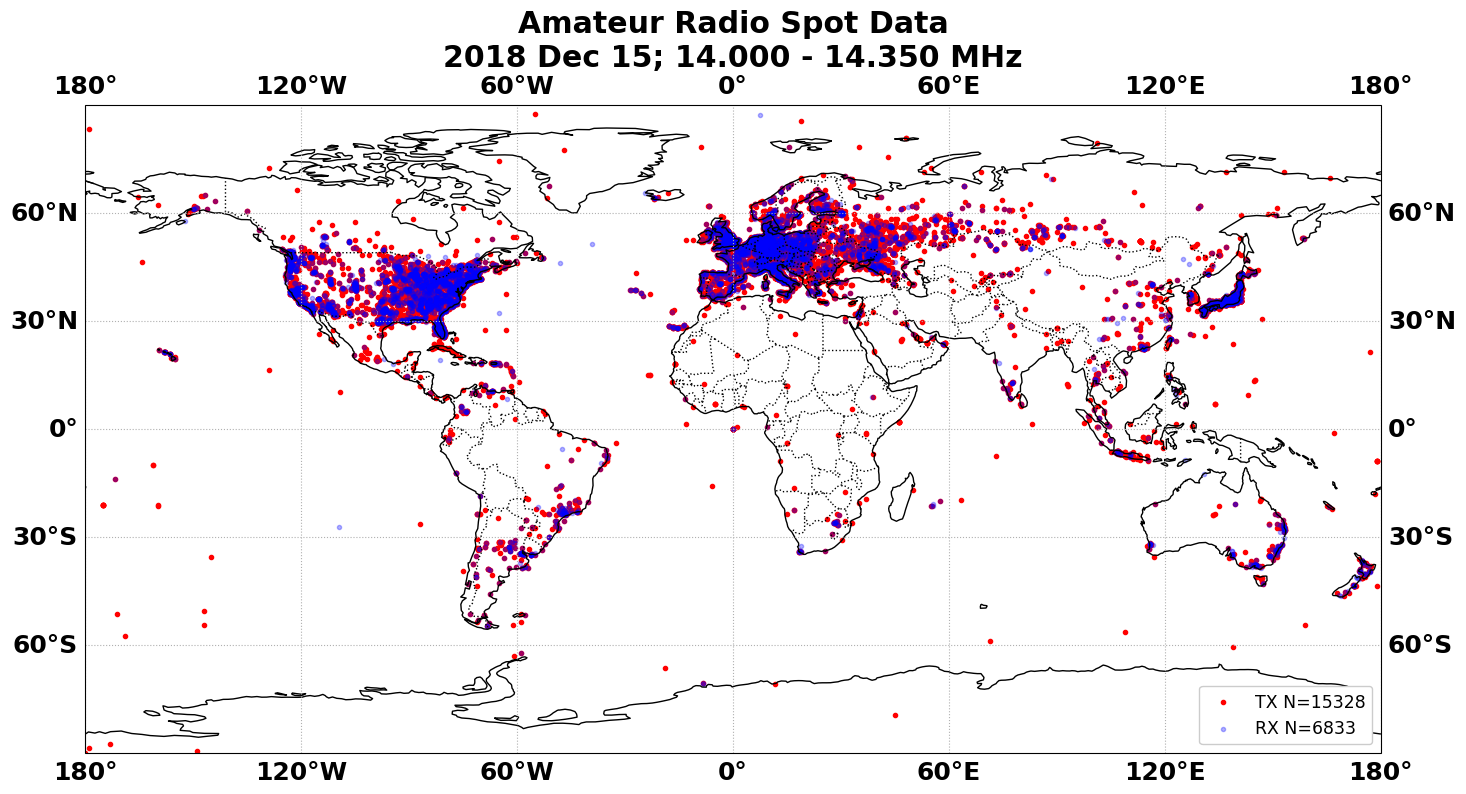

In [12]:
# World
xlim    = (-180,180)
ylim    = (-90,90)

# # Continental US (CONUS)
# xlim    = (-130,-56)
# ylim    = (20,55)

## CONUS + Canada
#xlim    = (-130,-56)
#ylim    = (20,80)

fig     = plt.figure(figsize=(15,8))
ax      = fig.add_subplot(111,projection=ccrs.PlateCarree())
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS, linestyle=':')
ax.set_title('')
ax.gridlines(draw_labels=True)

# Transmitters
xx = tx_df['txlon']
yy = tx_df['txlat']
ax.scatter(xx,yy,marker='.',color='r',label=f'TX N={len(xx)}')

# Receivers
xx = rx_df['rxlon']
yy = rx_df['rxlat']
ax.scatter(xx,yy,marker='.',color='b',alpha=0.3,label=f'RX N={len(xx)}')


ax.legend(loc='lower right',prop={'size':'x-small','weight':'normal'},framealpha=1)
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

title = []
title.append('Amateur Radio Spot Data')
date_str = date.strftime('%Y %b %d')
f_str    = '{:0.3f} - {:0.3f} MHz'.format(frange[0]/1e6,frange[1]/1e6)
title.append(f'{date_str}; {f_str}')
ax.set_title('\n'.join(title))

plt.tight_layout()
plt.show()

In [13]:
paths = len(tx_df) * len(rx_df)
print(f'Theoretical TX-RX Paths: {paths:,}')
print()

hrs      = 12
dt_min   = 10
n_steps  = int((hrs*60) / dt_min)
n_traces = n_steps * paths
print('Simulation Calculator')
print(f'  Duration [hr]:  {hrs}')
print(f'  Cadence  [min]: {dt_min}')
print(f'  N Time Steps:   {n_steps}')
print(f'  N Traces:       {n_traces:,}')

Theoretical TX-RX Paths: 104,736,224

Simulation Calculator
  Duration [hr]:  12
  Cadence  [min]: 10
  N Time Steps:   72
  N Traces:       7,541,008,128
